In [1]:
import rasterio
import numpy as np
import glob

# Path template
path_template = "data/derived/resampled/biotic_gridded_1km_all_years_severity_30m_resampled_masked_*.tif"
raster_paths = sorted(glob.glob(path_template))  # ensure 2000→2020 order

# Collect all non-zero pixels
all_data = []

for path in raster_paths:
    with rasterio.open(path) as src:
        data = src.read(1)
        # Only include non-zero values
        all_data.append(data[data > 0.5])

# Flatten all years into one array
all_data_flat = np.concatenate(all_data)
print(f"Total pixels considered: {all_data_flat.size}")


Total pixels considered: 1148527438


In [2]:
# Example percentiles
p_25 = 25  
p_50 = 50  
p_75 = 75  
p_90 = 90  
p_95 = 95  
p_99 = 99  

# Compute
p25_threshold = np.percentile(all_data_flat, p_25)
p50_threshold = np.percentile(all_data_flat, p_50)
p75_threshold = np.percentile(all_data_flat, p_75)
p90_threshold = np.percentile(all_data_flat, p_90)
p95_threshold = np.percentile(all_data_flat, p_95)
p99_threshold = np.percentile(all_data_flat, p_99)

print(f"'Extreme disturbance' threshold (25th percentile): {p25_threshold:.2f}")
print(f"'Extreme disturbance' threshold (50th percentile): {p50_threshold:.2f}")
print(f"'Extreme disturbance' threshold (75th percentile): {p75_threshold:.2f}")
print(f"'Extreme disturbance' threshold (90th percentile): {p90_threshold:.2f}")
print(f"'Extreme disturbance' threshold (95th percentile): {p95_threshold:.2f}")
print(f"'Extreme disturbance' threshold (99th percentile): {p99_threshold:.2f}")


'Extreme disturbance' threshold (25th percentile): 0.90
'Extreme disturbance' threshold (50th percentile): 1.72
'Extreme disturbance' threshold (75th percentile): 3.86
'Extreme disturbance' threshold (90th percentile): 8.53
'Extreme disturbance' threshold (95th percentile): 14.94
'Extreme disturbance' threshold (99th percentile): 32.31


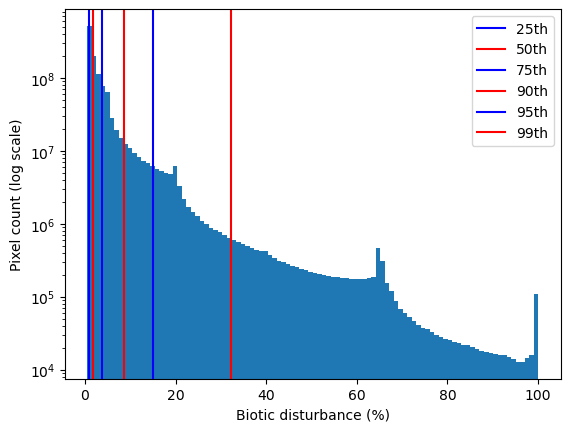

In [3]:
import matplotlib.pyplot as plt

plt.hist(all_data_flat, bins=100, log=True)
plt.axvline(p25_threshold, color='blue', label='25th')
plt.axvline(p50_threshold, color='red', label='50th')
plt.axvline(p75_threshold, color='blue', label='75th')
plt.axvline(p90_threshold, color='red', label='90th')
plt.axvline(p95_threshold, color='blue', label='95th')
plt.axvline(p99_threshold, color='red', label='99th')
plt.xlabel('Biotic disturbance (%)')
plt.ylabel('Pixel count (log scale)')
plt.legend()
plt.show()


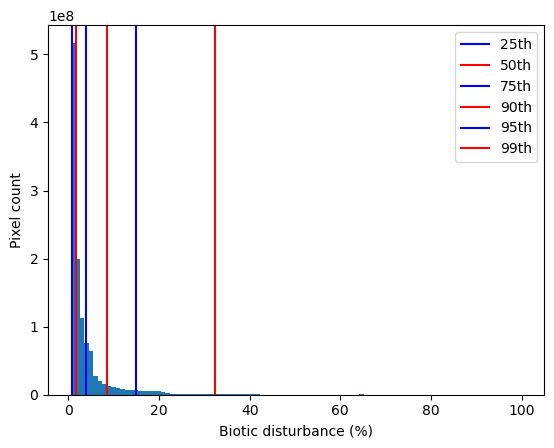

In [4]:
import matplotlib.pyplot as plt

plt.hist(all_data_flat, bins=100)
plt.axvline(p25_threshold, color='blue', label='25th')
plt.axvline(p50_threshold, color='red', label='50th')
plt.axvline(p75_threshold, color='blue', label='75th')
plt.axvline(p90_threshold, color='red', label='90th')
plt.axvline(p95_threshold, color='blue', label='95th')
plt.axvline(p99_threshold, color='red', label='99th')
plt.xlabel('Biotic disturbance (%)')
plt.ylabel('Pixel count')
plt.legend()
plt.show()


In [5]:
import numpy as np

# all_data_flat already contains all non-zero pixels across 2000-2020

# Basic statistics
min_val = np.min(all_data_flat)
max_val = np.max(all_data_flat)
mean_val = np.mean(all_data_flat)
median_val = np.median(all_data_flat)
std_val = np.std(all_data_flat)

# Percentiles
p10, p25, p50, p75, p90, p95, p99 = np.percentile(all_data_flat, [10, 25, 50, 75, 90, 95, 99])

# Display
print("Summary statistics for biotic disturbance stack (non-zero pixels):")
print(f"Min: {min_val:.2f}")
print(f"Max: {max_val:.2f}")
print(f"Mean: {mean_val:.2f}")
print(f"Median: {median_val:.2f}")
print(f"Std dev: {std_val:.2f}")
print(f"10th percentile: {p10:.2f}")
print(f"25th percentile: {p25:.2f}")
print(f"50th percentile (median): {p50:.2f}")
print(f"75th percentile: {p75:.2f}")
print(f"90th percentile: {p90:.2f}")
print(f"95th percentile: {p95:.2f}")
print(f"99th percentile: {p99:.2f}")

Summary statistics for biotic disturbance stack (non-zero pixels):
Min: 0.50
Max: 100.00
Mean: 3.81
Median: 1.72
Std dev: 6.52
10th percentile: 0.63
25th percentile: 0.90
50th percentile (median): 1.72
75th percentile: 3.86
90th percentile: 8.53
95th percentile: 14.94
99th percentile: 32.31
